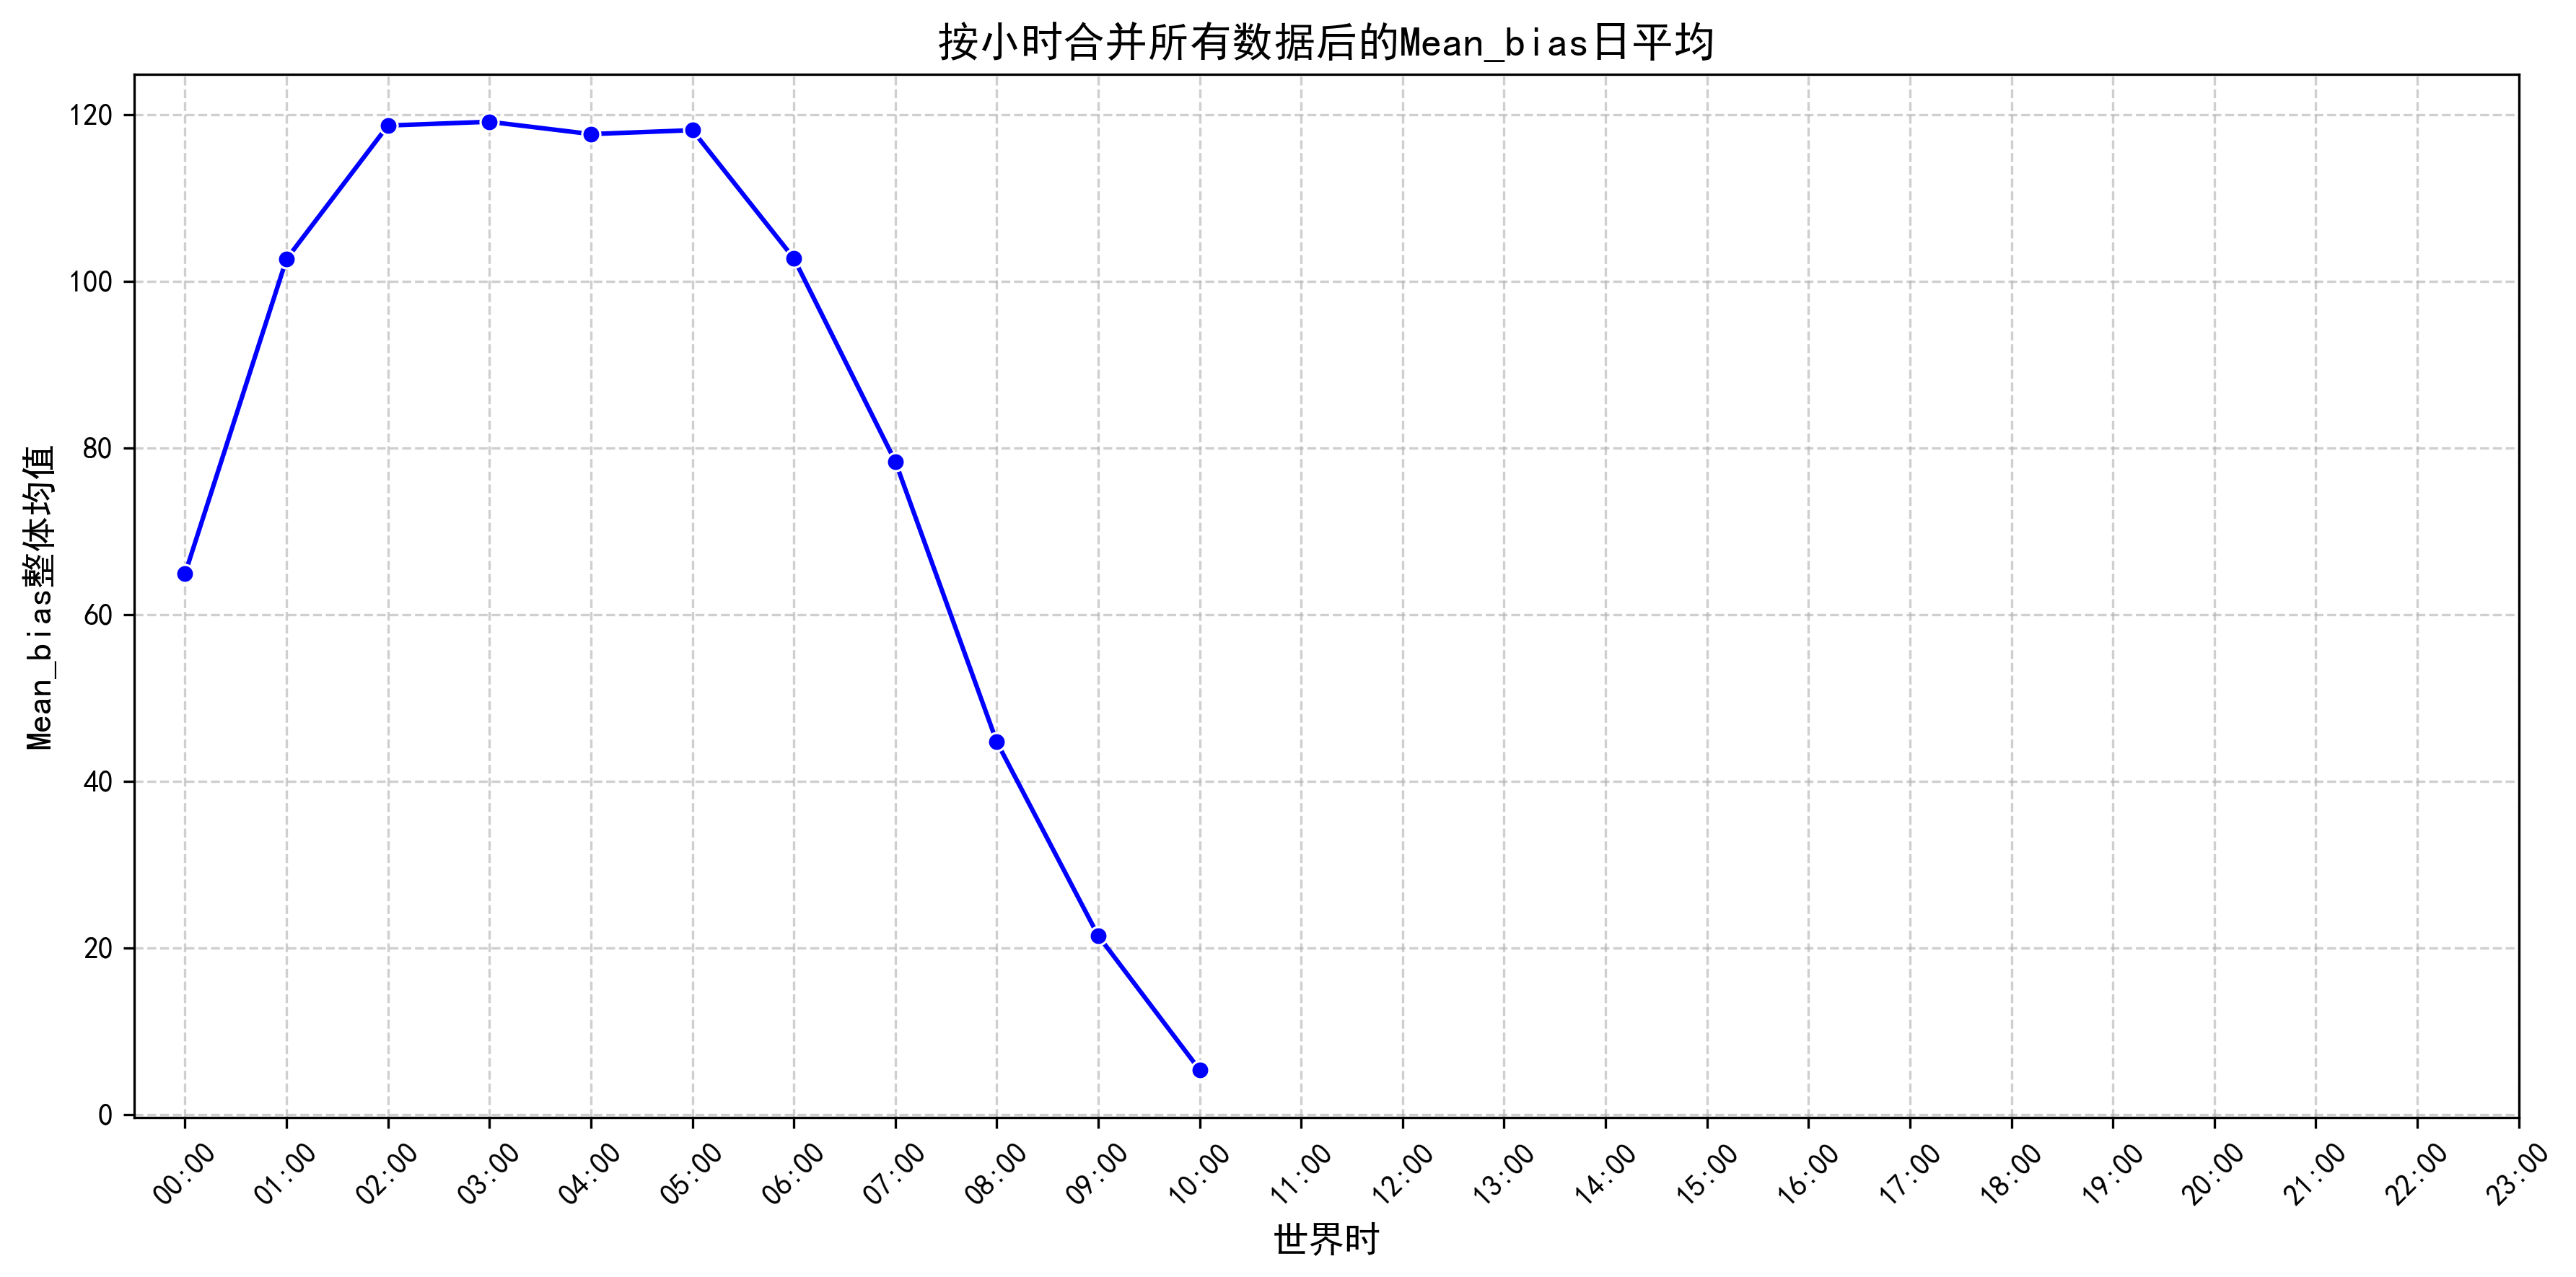

In [3]:
import pandas as pd
import glob
import os
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 基础路径
base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
file_list = glob.glob(file_pattern, recursive=True)

# 初始化字典：按小时存储所有Mean Bias数据（不预先计算单文件均值）
hourly_raw_data = {}

for file in file_list:
    try:
        # 提取小时
        filename = os.path.basename(file)
        datetime_str = filename.split('_')[-2][:10]  # 提取YYYYMMDDHH
        time_obj = datetime.strptime(datetime_str, "%Y%m%d%H")
        hour = time_obj.hour
        
        # 读取CSV文件
        df = pd.read_csv(file)
        
        # 检查列是否存在并提取所有Mean Bias数据
        if 'Mean Bias' in df.columns:
            valid_values = df['Mean Bias'].replace([-999],np.nan).dropna()  # 去除NaN
            if not valid_values.empty:
                if hour not in hourly_raw_data:
                    hourly_raw_data[hour] = []
                hourly_raw_data[hour].extend(valid_values.tolist())  # 合并原始数据
    
    except Exception as e:
        print(f"处理文件 {filename} 时出错: {e}")
        continue

# 计算每小时的整体均值
# hourly_avg = {}
# for hour, values in hourly_raw_data.items():
#     if values:  # 确保有数据
#         hourly_avg[hour] = np.mean(values)
#     else:
#         hourly_avg[hour] = np.nan  # 如果没有数据，设为NaN
hourly_avg = {hour: np.mean(values) for hour, values in hourly_raw_data.items()}

# 补全24小时（如果某些小时无数据，设为NaN）
hourly_avg_complete = {h: hourly_avg.get(h, np.nan) for h in range(24)}

# 转换为DataFrame用于绘图
df_plot = pd.DataFrame({
    'Hour': list(hourly_avg_complete.keys()),
    'Mean_bias': list(hourly_avg_complete.values())
})

# 绘制日平均分布图
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='Hour', y='Mean_bias', marker='o', color='b')
plt.title('按小时合并所有数据后的Mean_bias日平均', fontsize=14)
plt.xlabel('世界时', fontsize=12)
plt.ylabel('Mean_bias整体均值', fontsize=12)
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

找到 744 个文件，开始处理...


处理文件中: 100%|██████████| 744/744 [00:02<00:00, 354.72it/s]


生成中国全境Bias填色图...
站点平均值清洗后保留 167 个有效站点
正在执行克里金插值...（可能需要几分钟）


e:\miniconda\envs\data\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


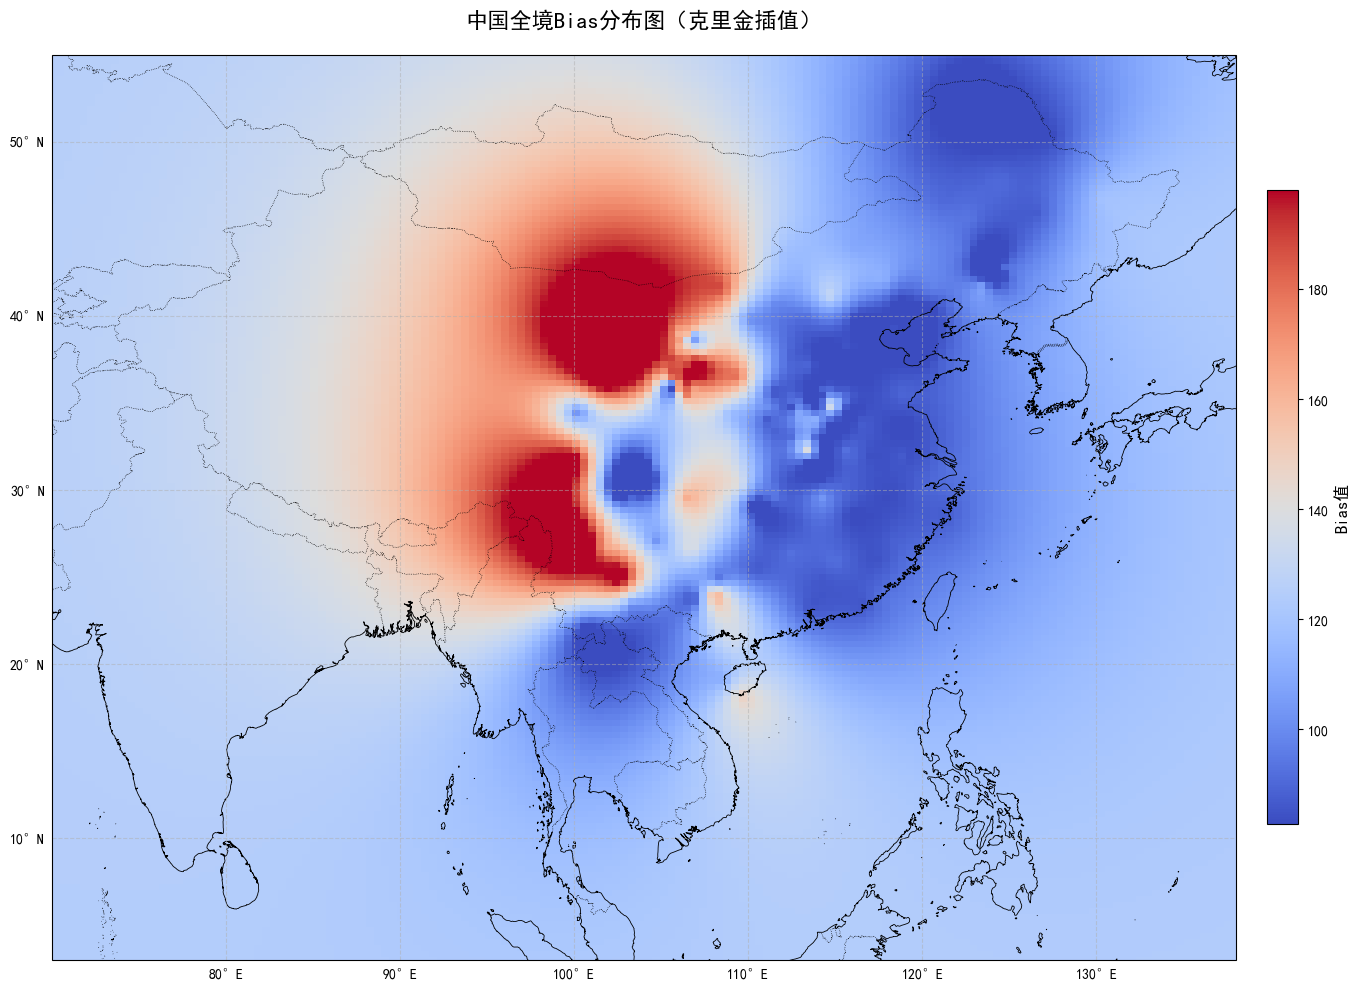

In [12]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging  # 引入克里金插值库

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，包含中国全境数据，并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 核心：将异常值替换为缺失值（NaN）
        # 包含9999、-999、999999，同时处理可能的字符串格式异常值
        异常值列表 = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(异常值列表, np.nan)
        
        # 过滤经纬度范围，并移除bias为缺失值的行
        valid_mask = (
            df['bias'].notna() &  # 仅保留非缺失的bias值
            df['Lon'].between(70, 138) &  # 东经70-138度
            df['Lat'].between(3, 55)      # 北纬3-55度
        )
        cleaned_df = df[valid_mask].copy()
        
        # 打印清洗信息（可选，用于调试）
        #print(f"文件 {os.path.basename(file)} 清洗后保留 {len(cleaned_df)} 条有效数据")
        return cleaned_df
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件并合并数据"""
    data_list = []
    for file in tqdm(file_list, desc="处理文件中"):
        try:
            filename = os.path.basename(file)
            date_str = filename.split('_')[-2][:8]
            date = datetime.strptime(date_str, "%Y%m%d").date()
            
            df = safe_read_csv(file)
            if df is not None and not df.empty:
                df['Date'] = date
                data_list.append(df[['Date', 'Lon', 'Lat', 'bias']])
        except Exception as e:
            print(f"处理文件 {filename} 时出错: {str(e)}")
    
    if not data_list:
        raise ValueError("未找到有效数据")
    all_data = pd.concat(data_list, ignore_index=True, copy=False)
    
    # 再次检查并清洗合并后的数据（双重保障）
    # all_data['bias'] = all_data['bias'].replace([9999, -999, 999999], np.nan).dropna() # 去除NaN
    # print(f"所有文件合并后共保留 {len(all_data)} 条有效数据")
    return all_data

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """使用普通克里金方法进行插值"""
    # 创建网格点
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    # 执行克里金插值（尝试更稳健的模型）
    OK = OrdinaryKriging(
        lon, lat, values, 
        variogram_model='exponential',  # 指数模型可能更适合部分数据
        verbose=False, 
        enable_plotting=False,
        nlags=8,  # 增加滞后距离数，提高稳定性
    )
    
    # 插值计算
    z, ss = OK.execute('grid', gridx, gridy)
    return z

def plot_china_bias(data):
    """绘制覆盖中国全境的Bias填色图（使用克里金插值）"""
    # 计算站点平均值（所有日期）
    station_avg = data.groupby(['Lon', 'Lat'], as_index=False)['bias'].mean()
    
    # 再次清洗平均值中的异常值（防止极端值影响）
    bias_mean = station_avg['bias'].mean()
    bias_std = station_avg['bias'].std()
    # 保留均值±3倍标准差范围内的数据（3σ准则）
    station_avg = station_avg[
        (station_avg['bias'] >= bias_mean - 3*bias_std) &
        (station_avg['bias'] <= bias_mean + 3*bias_std)
    ]
    print(f"站点平均值清洗后保留 {len(station_avg)} 个有效站点")
    
    # 创建覆盖中国全境的网格
    grid_lon = np.linspace(70, 138, 150, dtype='float32')
    grid_lat = np.linspace(3, 55, 150, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 准备克里金插值数据
    lon = station_avg['Lon'].values
    lat = station_avg['Lat'].values
    bias = station_avg['bias'].values
    
    # 执行克里金插值
    print("正在执行克里金插值...（可能需要几分钟）")
    grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
    
    # 创建图形
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
    # 添加高精度地图要素
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='#E6F7FF', alpha=0.2)
    
    # 设置中国全境范围
    ax.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    # 动态调整颜色映射范围（关键：基于实际数据分布）
    vmin = np.nanpercentile(grid_bias, 2)  # 排除2%的极端小值
    vmax = np.nanpercentile(grid_bias, 98)  # 排除2%的极端大值
    
    # 绘制填色图
    pcm = ax.pcolormesh(
        grid_lon, grid_lat, grid_bias,
        cmap='coolwarm',
        vmin=vmin, vmax=vmax,  # 自适应数据范围
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    # 添加颜色条
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Bias值', fontsize=12)
    
    # 添加网格和标题
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    plt.title('中国全境Bias分布图（克里金插值）', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()


def main():
    # 文件路径设置
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    all_data = process_files(file_list)
    
    # 绘制中国全境填色图
    print("生成中国全境Bias填色图...")
    plot_china_bias(all_data)

if __name__ == '__main__':
    main()

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging
from matplotlib.animation import FuncAnimation, PillowWriter

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，提取小时信息并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 异常值处理
        abnormal_values = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(abnormal_values, np.nan)
        
        # 过滤经纬度范围和有效数据
        valid_mask = (
            df['bias'].notna() &
            df['Lon'].between(70, 138) &
            df['Lat'].between(3, 55)
        )
        cleaned_df = df[valid_mask].copy()
        
        # 从文件名提取小时信息
        filename = os.path.basename(file)
        try:
            time_str = filename.split('_')[-2][8:10]  # 提取小时部分
            hour = int(time_str)
            cleaned_df['hour'] = hour
            return cleaned_df
        except:
            print(f"文件 {filename} 无法提取小时信息")
            return None
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件，按小时聚合数据"""
    all_data = []
    for file in tqdm(file_list, desc="处理文件中"):
        df = safe_read_csv(file)
        if df is not None and not df.empty:
            all_data.append(df)
    
    if not all_data:
        raise ValueError("未找到有效数据")
    
    combined = pd.concat(all_data, ignore_index=True)
    hourly_data = combined.groupby(['hour', 'Lon', 'Lat'])['bias'].mean().reset_index()
    unique_hours = sorted(hourly_data['hour'].unique())
    print(f"成功提取 {len(unique_hours)} 个小时的数据（0-23时）")
    return hourly_data, unique_hours

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """克里金插值"""
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    if len(lon) < 3:
        return np.full((len(gridy), len(gridx)), np.nan)
    
    try:
        OK = OrdinaryKriging(
            lon, lat, values, 
            variogram_model='exponential',
            verbose=False, 
            enable_plotting=False,
            nlags=8,
        )
        z, _ = OK.execute('grid', gridx, gridy)
        return z
    except:
        return np.full((len(gridy), len(gridx)), np.nan)

def plot_and_save_animation(hourly_data, unique_hours):
    """生成并保存动图（无交互控件）"""
    # 创建网格
    grid_lon = np.linspace(70, 138, 120, dtype='float32')
    grid_lat = np.linspace(3, 55, 120, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 预处理插值结果
    interpolated = []
    hourly_stats = []
    all_biases = hourly_data['bias'].dropna().values
    global_vmin = np.nanpercentile(all_biases, 2)
    global_vmax = np.nanpercentile(all_biases, 98)
    
    print("预处理所有小时的插值结果...")
    for hour in tqdm(unique_hours, desc="插值计算中"):
        hour_data = hourly_data[hourly_data['hour'] == hour]
        
        # 3σ清洗
        if len(hour_data) > 5:
            mean_val = hour_data['bias'].mean()
            std_val = hour_data['bias'].std()
            hour_data = hour_data[(hour_data['bias'] >= mean_val - 3*std_val) &
                                 (hour_data['bias'] <= mean_val + 3*std_val)]
        
        # 插值
        lon = hour_data['Lon'].values
        lat = hour_data['Lat'].values
        bias = hour_data['bias'].values
        grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
        interpolated.append(grid_bias)
        
        # 记录统计信息
        hourly_stats.append({
            'hour': hour,
            'mean_bias': hour_data['bias'].mean(),
            'std_bias': hour_data['bias'].std(),
            'count': len(hour_data)
        })
    
    # 创建图形（双面板布局）
    fig = plt.figure(figsize=(20, 8), dpi=150)
    ax_map = fig.add_subplot(121, projection=ccrs.PlateCarree())
    ax_diurnal = fig.add_subplot(122)
    
    # 左侧：空间分布图初始化
    ax_map.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax_map.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax_map.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    pcm = ax_map.pcolormesh(
        grid_lon, grid_lat, interpolated[0],
        cmap='coolwarm',
        vmin=global_vmin, vmax=global_vmax,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    cbar = fig.colorbar(pcm, ax=ax_map, shrink=0.7, pad=0.02)
    cbar.set_label('小时平均Bias值', fontsize=12)
    
    gl = ax_map.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    map_title = ax_map.set_title(
        f'小时平均Bias分布 ({unique_hours[0]:02d}时)',
        fontsize=14, pad=20
    )
    
    # 右侧：日变化周期图初始化
    hours = [stat['hour'] for stat in hourly_stats]
    means = [stat['mean_bias'] for stat in hourly_stats]
    stds = [stat['std_bias'] for stat in hourly_stats]
    
    ax_diurnal.plot(hours, means, 'o-', color='blue', label='小时平均偏差')
    ax_diurnal.fill_between(
        hours,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        color='blue', alpha=0.2, label='±1标准差'
    )
    ax_diurnal.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    for i, stat in enumerate(hourly_stats):
        ax_diurnal.text(stat['hour'], stat['mean_bias'] + 0.1, 
                       f"{stat['count']}", ha='center', fontsize=9)
    
    ax_diurnal.set_xticks(range(0, 24, 2))
    ax_diurnal.set_xlim(-1, 24)
    ax_diurnal.set_title('小时平均偏差日变化周期', fontsize=14, pad=20)
    ax_diurnal.set_xlabel('小时 (UTC+8)', fontsize=12)
    ax_diurnal.set_ylabel('平均Bias值', fontsize=12)
    ax_diurnal.grid(True, linestyle='--', alpha=0.6)
    ax_diurnal.legend()
    
    vline = ax_diurnal.axvline(x=hours[0], color='green', linestyle='-', linewidth=2)
    
    # 动画帧更新函数
    def update(frame):
        hour = unique_hours[frame]
        # 更新空间分布图
        pcm.set_array(interpolated[frame].ravel())
        map_title.set_text(f'小时平均Bias分布 ({hour:02d}时)')
        
        # 更新日变化周期标记线
        vline.set_xdata([hour])
        
        return pcm, map_title, vline  # 返回需要更新的元素
    
    # 创建动画并保存
    print("开始保存动图...")
    ani = FuncAnimation(
        fig,
        update,
        frames=len(unique_hours),
        interval=800,  # 每帧停留800ms
        blit=True,
        repeat=True  # 循环播放
    )
    
    # 保存到当前目录
    save_path = "hourly_bias_animation.gif"
    ani.save(
        save_path,
        writer=PillowWriter(fps=1.25),  # 1.25帧/秒 = 每帧0.8秒
        dpi=150
    )
    
    print(f"动图已保存至：{os.path.abspath(save_path)}")
    plt.close(fig)  # 不显示图形界面，直接关闭

def main():
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    hourly_data, unique_hours = process_files(file_list)
    
    # 直接生成并保存动图，无交互界面
    print("生成并保存小时级动态分布图...")
    plot_and_save_animation(hourly_data, unique_hours)

if __name__ == '__main__':
    main()

找到 744 个文件，开始处理...


处理文件中: 100%|██████████| 744/744 [00:02<00:00, 336.27it/s]


成功提取 11 个小时的数据（0-23时）
生成并保存小时级动态分布图...
预处理所有小时的插值结果...


插值计算中: 100%|██████████| 11/11 [00:01<00:00,  6.20it/s]


开始保存动图...
动图已保存至：d:\程序设计\hourly_bias_animation.gif


找到 742 个文件，开始处理...


处理文件中: 100%|██████████| 742/742 [00:02<00:00, 300.97it/s]


生成中国全境Bias填色图...
站点平均值清洗后保留 167 个有效站点
正在执行克里金插值...（可能需要几分钟）


e:\miniconda\envs\data\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


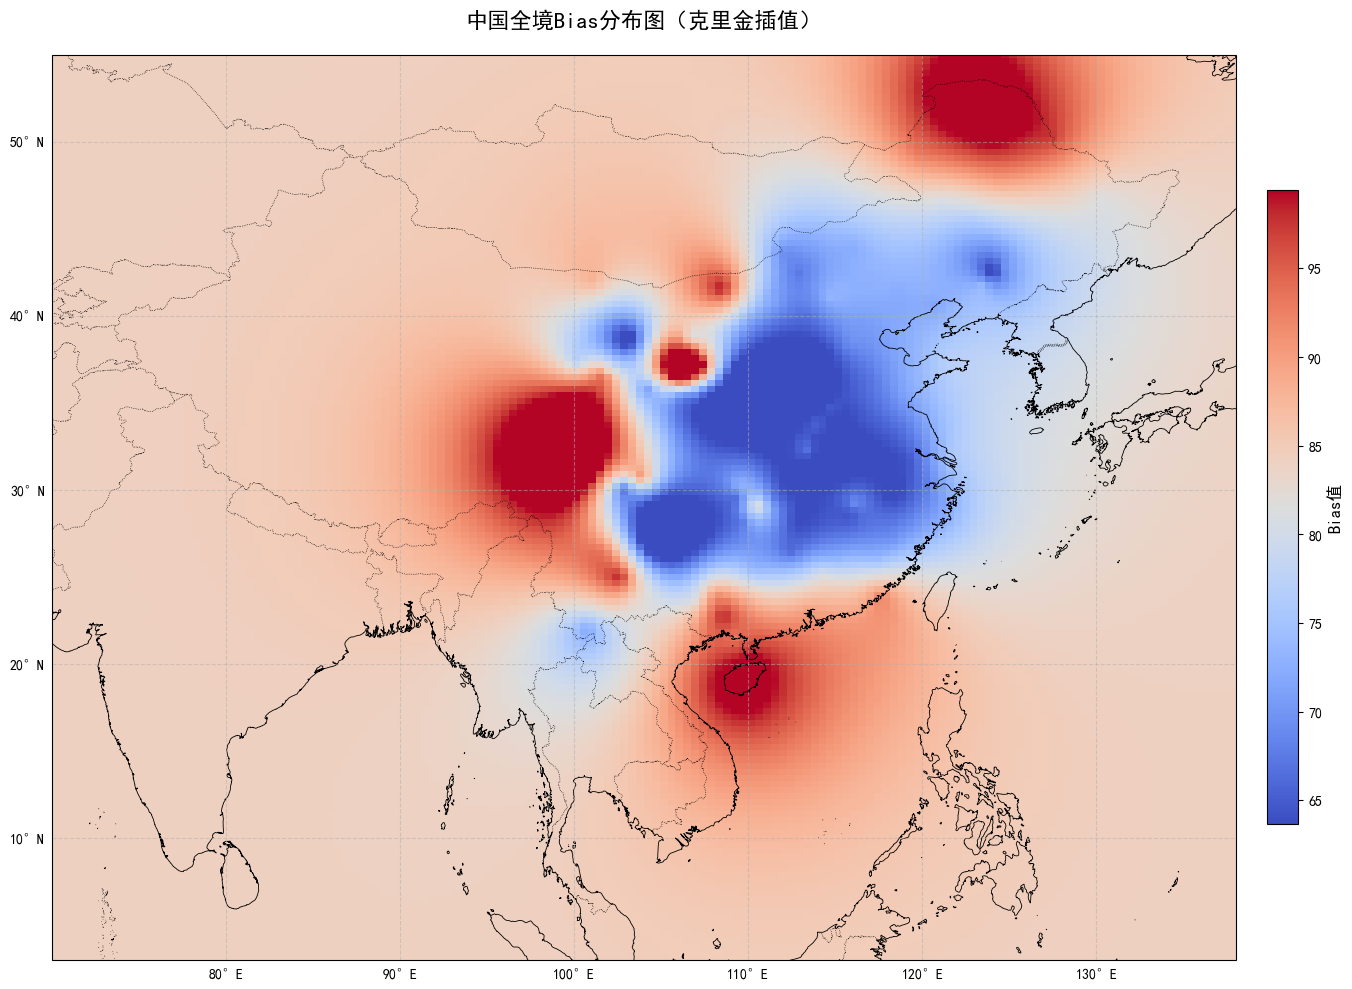

In [2]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging  # 引入克里金插值库

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，包含中国全境数据，并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 核心：将异常值替换为缺失值（NaN）
        # 包含9999、-999、999999，同时处理可能的字符串格式异常值
        异常值列表 = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(异常值列表, np.nan)
        
        # 过滤经纬度范围，并移除bias为缺失值的行
        valid_mask = (
            df['bias'].notna() &  # 仅保留非缺失的bias值
            df['Lon'].between(70, 138) &  # 东经70-138度
            df['Lat'].between(3, 55)      # 北纬3-55度
        )
        cleaned_df = df[valid_mask].copy()
        
        # 打印清洗信息（可选，用于调试）
        #print(f"文件 {os.path.basename(file)} 清洗后保留 {len(cleaned_df)} 条有效数据")
        return cleaned_df
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件并合并数据"""
    data_list = []
    for file in tqdm(file_list, desc="处理文件中"):
        try:
            filename = os.path.basename(file)
            date_str = filename.split('_')[-2][:8]
            date = datetime.strptime(date_str, "%Y%m%d").date()
            
            df = safe_read_csv(file)
            if df is not None and not df.empty:
                df['Date'] = date
                data_list.append(df[['Date', 'Lon', 'Lat', 'bias']])
        except Exception as e:
            print(f"处理文件 {filename} 时出错: {str(e)}")
    
    if not data_list:
        raise ValueError("未找到有效数据")
    all_data = pd.concat(data_list, ignore_index=True, copy=False)
    
    # 再次检查并清洗合并后的数据（双重保障）
    # all_data['bias'] = all_data['bias'].replace([9999, -999, 999999], np.nan).dropna() # 去除NaN
    # print(f"所有文件合并后共保留 {len(all_data)} 条有效数据")
    return all_data

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """使用普通克里金方法进行插值"""
    # 创建网格点
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    # 执行克里金插值（尝试更稳健的模型）
    OK = OrdinaryKriging(
        lon, lat, values, 
        variogram_model='exponential',  # 指数模型可能更适合部分数据
        verbose=False, 
        enable_plotting=False,
        nlags=8,  # 增加滞后距离数，提高稳定性
    )
    
    # 插值计算
    z, ss = OK.execute('grid', gridx, gridy)
    return z

def plot_china_bias(data):
    """绘制覆盖中国全境的Bias填色图（使用克里金插值）"""
    # 计算站点平均值（所有日期）
    station_avg = data.groupby(['Lon', 'Lat'], as_index=False)['bias'].mean()
    
    # 再次清洗平均值中的异常值（防止极端值影响）
    bias_mean = station_avg['bias'].mean()
    bias_std = station_avg['bias'].std()
    # 保留均值±3倍标准差范围内的数据（3σ准则）
    station_avg = station_avg[
        (station_avg['bias'] >= bias_mean - 3*bias_std) &
        (station_avg['bias'] <= bias_mean + 3*bias_std)
    ]
    print(f"站点平均值清洗后保留 {len(station_avg)} 个有效站点")
    
    # 创建覆盖中国全境的网格
    grid_lon = np.linspace(70, 138, 150, dtype='float32')
    grid_lat = np.linspace(3, 55, 150, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 准备克里金插值数据
    lon = station_avg['Lon'].values
    lat = station_avg['Lat'].values
    bias = station_avg['bias'].values
    
    # 执行克里金插值
    print("正在执行克里金插值...（可能需要几分钟）")
    grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
    
    # 创建图形
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
    # 添加高精度地图要素
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='#E6F7FF', alpha=0.2)
    
    # 设置中国全境范围
    ax.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    # 动态调整颜色映射范围（关键：基于实际数据分布）
    vmin = np.nanpercentile(grid_bias, 2)  # 排除2%的极端小值
    vmax = np.nanpercentile(grid_bias, 98)  # 排除2%的极端大值
    
    # 绘制填色图
    pcm = ax.pcolormesh(
        grid_lon, grid_lat, grid_bias,
        cmap='coolwarm',
        vmin=vmin, vmax=vmax,  # 自适应数据范围
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    # 添加颜色条
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Bias值', fontsize=12)
    
    # 添加网格和标题
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    plt.title('中国全境Bias分布图（克里金插值）', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()


def main():
    # 文件路径设置
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    #使用修正后的数据
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI-correct_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    all_data = process_files(file_list)
    
    # 绘制中国全境填色图
    print("生成中国全境Bias填色图...")
    plot_china_bias(all_data)

if __name__ == '__main__':
    main()

In [13]:
#修改之后
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging
from matplotlib.animation import FuncAnimation, PillowWriter

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，提取小时信息并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 异常值处理
        abnormal_values = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(abnormal_values, np.nan)
        
        # 过滤经纬度范围和有效数据
        valid_mask = (
            df['bias'].notna() &
            df['Lon'].between(70, 138) &
            df['Lat'].between(3, 55)
        )
        cleaned_df = df[valid_mask].copy()
        
        # 从文件名提取小时信息
        filename = os.path.basename(file)
        try:
            time_str = filename.split('_')[-2][8:10]  # 提取小时部分
            hour = int(time_str)
            cleaned_df['hour'] = hour
            return cleaned_df
        except:
            print(f"文件 {filename} 无法提取小时信息")
            return None
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件，按小时聚合数据"""
    all_data = []
    for file in tqdm(file_list, desc="处理文件中"):
        df = safe_read_csv(file)
        if df is not None and not df.empty:
            all_data.append(df)
    
    if not all_data:
        raise ValueError("未找到有效数据")
    
    combined = pd.concat(all_data, ignore_index=True)
    hourly_data = combined.groupby(['hour', 'Lon', 'Lat'])['bias'].mean().reset_index()
    unique_hours = sorted(hourly_data['hour'].unique())
    print(f"成功提取 {len(unique_hours)} 个小时的数据（0-23时）")
    return hourly_data, unique_hours

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """克里金插值"""
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    if len(lon) < 3:
        return np.full((len(gridy), len(gridx)), np.nan)
    
    try:
        OK = OrdinaryKriging(
            lon, lat, values, 
            variogram_model='exponential',
            verbose=False, 
            enable_plotting=False,
            nlags=8,
        )
        z, _ = OK.execute('grid', gridx, gridy)
        return z
    except:
        return np.full((len(gridy), len(gridx)), np.nan)

def plot_and_save_animation(hourly_data, unique_hours):
    """生成并保存动图（无交互控件）"""
    # 创建网格
    grid_lon = np.linspace(70, 138, 120, dtype='float32')
    grid_lat = np.linspace(3, 55, 120, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 预处理插值结果
    interpolated = []
    hourly_stats = []
    all_biases = hourly_data['bias'].dropna().values
    global_vmin = np.nanpercentile(all_biases, 2)
    global_vmax = np.nanpercentile(all_biases, 98)
    
    print("预处理所有小时的插值结果...")
    for hour in tqdm(unique_hours, desc="插值计算中"):
        hour_data = hourly_data[hourly_data['hour'] == hour]
        
        # 3σ清洗
        if len(hour_data) > 5:
            mean_val = hour_data['bias'].mean()
            std_val = hour_data['bias'].std()
            hour_data = hour_data[(hour_data['bias'] >= mean_val - 3*std_val) &
                                 (hour_data['bias'] <= mean_val + 3*std_val)]
        
        # 插值
        lon = hour_data['Lon'].values
        lat = hour_data['Lat'].values
        bias = hour_data['bias'].values
        grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
        interpolated.append(grid_bias)
        
        # 记录统计信息
        hourly_stats.append({
            'hour': hour,
            'mean_bias': hour_data['bias'].mean(),
            'std_bias': hour_data['bias'].std(),
            'count': len(hour_data)
        })
    
    # 创建图形（双面板布局）
    fig = plt.figure(figsize=(20, 8), dpi=150)
    ax_map = fig.add_subplot(121, projection=ccrs.PlateCarree())
    ax_diurnal = fig.add_subplot(122)
    
    # 左侧：空间分布图初始化
    ax_map.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax_map.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax_map.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    pcm = ax_map.pcolormesh(
        grid_lon, grid_lat, interpolated[0],
        cmap='coolwarm',
        vmin=global_vmin, vmax=global_vmax,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    cbar = fig.colorbar(pcm, ax=ax_map, shrink=0.7, pad=0.02)
    cbar.set_label('小时平均Bias值', fontsize=12)
    
    gl = ax_map.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    map_title = ax_map.set_title(
        f'小时平均Bias分布 ({unique_hours[0]:02d}时)',
        fontsize=14, pad=20
    )
    
    # 右侧：日变化周期图初始化
    hours = [stat['hour'] for stat in hourly_stats]
    means = [stat['mean_bias'] for stat in hourly_stats]
    stds = [stat['std_bias'] for stat in hourly_stats]
    
    ax_diurnal.plot(hours, means, 'o-', color='blue', label='小时平均偏差')
    ax_diurnal.fill_between(
        hours,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        color='blue', alpha=0.2, label='±1标准差'
    )
    ax_diurnal.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    for i, stat in enumerate(hourly_stats):
        ax_diurnal.text(stat['hour'], stat['mean_bias'] + 0.1, 
                       f"{stat['count']}", ha='center', fontsize=9)
    
    ax_diurnal.set_xticks(range(0, 24, 2))
    ax_diurnal.set_xlim(-1, 24)
    ax_diurnal.set_title('小时平均偏差日变化周期', fontsize=14, pad=20)
    ax_diurnal.set_xlabel('小时 (UTC+8)', fontsize=12)
    ax_diurnal.set_ylabel('平均Bias值', fontsize=12)
    ax_diurnal.grid(True, linestyle='--', alpha=0.6)
    ax_diurnal.legend()
    
    vline = ax_diurnal.axvline(x=hours[0], color='green', linestyle='-', linewidth=2)
    
    # 动画帧更新函数
    def update(frame):
        hour = unique_hours[frame]
        # 更新空间分布图
        pcm.set_array(interpolated[frame].ravel())
        map_title.set_text(f'小时平均Bias分布 ({hour:02d}时)')
        
        # 更新日变化周期标记线
        vline.set_xdata([hour])
        
        return pcm, map_title, vline  # 返回需要更新的元素
    
    # 创建动画并保存
    print("开始保存动图...")
    ani = FuncAnimation(
        fig,
        update,
        frames=len(unique_hours),
        interval=800,  # 每帧停留800ms
        blit=True,
        repeat=True  # 循环播放
    )
    
    # 保存到当前目录
    save_path = "修改后的日均偏差.gif"
    ani.save(
        save_path,
        writer=PillowWriter(fps=1.25),  # 1.25帧/秒 = 每帧0.8秒
        dpi=150
    )
    
    print(f"动图已保存至：{os.path.abspath(save_path)}")
    plt.close(fig)  # 不显示图形界面，直接关闭

def main():
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI-correct_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    hourly_data, unique_hours = process_files(file_list)
    
    # 直接生成并保存动图，无交互界面
    print("生成并保存小时级动态分布图...")
    plot_and_save_animation(hourly_data, unique_hours)

if __name__ == '__main__':
    main()

找到 742 个文件，开始处理...


处理文件中: 100%|██████████| 742/742 [00:01<00:00, 389.99it/s]


成功提取 11 个小时的数据（0-23时）
生成并保存小时级动态分布图...
预处理所有小时的插值结果...


插值计算中: 100%|██████████| 11/11 [00:01<00:00,  8.44it/s]


开始保存动图...
动图已保存至：d:\程序设计\修改后的日均偏差.gif


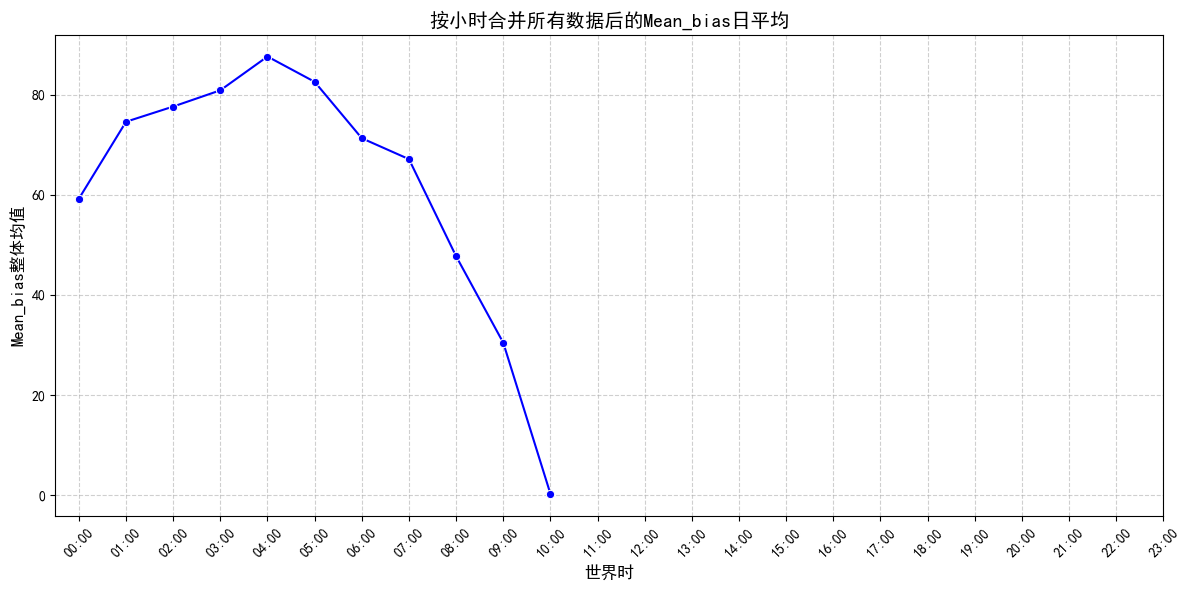

In [4]:
#修改后的数据
import pandas as pd
import glob
import os
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 基础路径
base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI-correct_CHN_4KM_*_0000-0000.CSV")
file_list = glob.glob(file_pattern, recursive=True)

# 初始化字典：按小时存储所有Mean Bias数据（不预先计算单文件均值）
hourly_raw_data = {}

for file in file_list:
    try:
        # 提取小时
        filename = os.path.basename(file)
        datetime_str = filename.split('_')[-2][:10]  # 提取YYYYMMDDHH
        time_obj = datetime.strptime(datetime_str, "%Y%m%d%H")
        hour = time_obj.hour
        
        # 读取CSV文件
        df = pd.read_csv(file)
        
        # 检查列是否存在并提取所有Mean Bias数据
        if 'Mean Bias' in df.columns:
            valid_values = df['Mean Bias'].replace([-999],np.nan).dropna()  # 去除NaN
            if not valid_values.empty:
                if hour not in hourly_raw_data:
                    hourly_raw_data[hour] = []
                hourly_raw_data[hour].extend(valid_values.tolist())  # 合并原始数据
    
    except Exception as e:
        print(f"处理文件 {filename} 时出错: {e}")
        continue

# 计算每小时的整体均值
# hourly_avg = {}
# for hour, values in hourly_raw_data.items():
#     if values:  # 确保有数据
#         hourly_avg[hour] = np.mean(values)
#     else:
#         hourly_avg[hour] = np.nan  # 如果没有数据，设为NaN
hourly_avg = {hour: np.mean(values) for hour, values in hourly_raw_data.items()}

# 补全24小时（如果某些小时无数据，设为NaN）
hourly_avg_complete = {h: hourly_avg.get(h, np.nan) for h in range(24)}

# 转换为DataFrame用于绘图
df_plot = pd.DataFrame({
    'Hour': list(hourly_avg_complete.keys()),
    'Mean_bias': list(hourly_avg_complete.values())
})

# 绘制日平均分布图
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='Hour', y='Mean_bias', marker='o', color='b')
plt.title('按小时合并所有数据后的Mean_bias日平均', fontsize=14)
plt.xlabel('世界时', fontsize=12)
plt.ylabel('Mean_bias整体均值', fontsize=12)
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

81.56893680949604
0      81.568937
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
101          NaN
102          NaN
103          NaN
104          NaN
105          NaN
Name: Mean Bias, Length: 106, dtype: float64
104.08534717718685
0      104.085347
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
101           NaN
102           NaN
103           NaN
104           NaN
105           NaN
Name: Mean Bias, Length: 106, dtype: float64
116.015530965764
0      116.015531
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
101           NaN
102           NaN
103           NaN
104           NaN
105           NaN
Name: Mean Bias, Length: 106, dtype: float64
135.84268209507457
0      135.842682
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
101           NaN
102           NaN
103           NaN
104           NaN
105           NaN
Name: Mean 

C:\Users\111\AppData\Local\Temp\ipykernel_9276\10016532.py:101: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
e:\miniconda\envs\data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


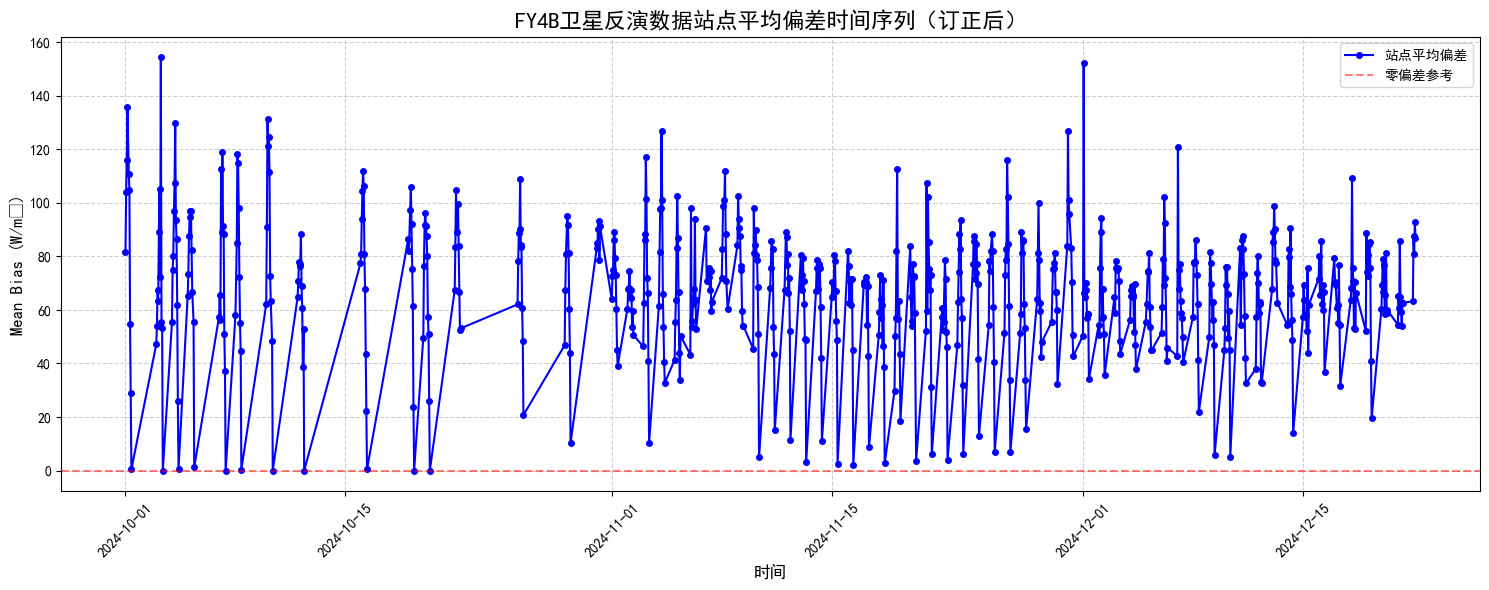

In [11]:
#订正后的图像
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates

# 设置中文字体显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 基础路径
base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"

def read_and_process_file(file):
    """读取并处理单个文件，返回时间戳和Mean Bias的平均值"""
    try:
        # 从文件名提取时间信息
        filename = os.path.basename(file)
        date_str = filename.split('_')[-2][:10]  # 提取 YYYYMMDDHH
        time_obj = datetime.strptime(date_str, '%Y%m%d%H')
        
        # 读取CSV文件
        ssi_csv = pd.read_csv(file, encoding='utf-8', sep=',')
        
        # 数据清洗
        ssi_csv = ssi_csv.replace([-999, 999999, 'NaN', 'NA', 'nan', 'NAN'], np.nan)
        
        if 'Mean Bias' not in ssi_csv.columns:
            print(f"文件 {filename} 中不存在'Mean Bias'列")
            return time_obj, None
        
        # 计算Mean Bias列的平均值
        mean_bias = ssi_csv['Mean Bias'].mean()  # 关键修改：确保返回单个平均值
        print(mean_bias)
        print(ssi_csv['Mean Bias'])
        return time_obj, mean_bias
            
    except Exception as e:
        print(f"处理文件 {file} 时出错: {str(e)}")
        return None, None

def main():
    # 查找所有CSV文件
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI-correct_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        print("未找到匹配的CSV文件")
        return
    
    # 收集数据
    time_data = []
    mean_bias_data = []
    
    for file in file_list:
        time_obj, mean_bias = read_and_process_file(file)
        if time_obj is not None and mean_bias is not None and not np.isnan(mean_bias):  # 确保不是None且不是NaN
            time_data.append(time_obj)
            mean_bias_data.append(mean_bias)
    
    if not mean_bias_data:
        print("没有有效数据用于绘图")
        return
    
    # 创建DataFrame并排序
    df = pd.DataFrame({'time': time_data, 'bias': mean_bias_data}).sort_values('time')
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # 绘制平均偏差曲线（确保x和y都是一维数组）
    ax.plot(
        df['time'], 
        df['bias'], 
        color='blue',
        linewidth=1.5,
        marker='o',
        markersize=4,
        label='站点平均偏差'
    )
    
    # 设置图形标题和标签
    ax.set_title("FY4B卫星反演数据站点平均偏差时间序列（订正后）", fontsize=16)
    ax.set_xlabel("时间", fontsize=12)
    ax.set_ylabel("Mean Bias (W/m²)", fontsize=12)
    
    # 设置时间轴格式
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45)
    
    # 添加网格和参考线
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='零偏差参考')
    ax.legend()
    
    # 自动调整布局
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

找到 742 个文件，开始处理...


处理文件中: 100%|██████████| 742/742 [00:02<00:00, 361.67it/s]


生成中国全境Bias填色图...
站点平均值清洗后保留 167 个有效站点
正在执行克里金插值...（可能需要几分钟）


e:\miniconda\envs\data\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


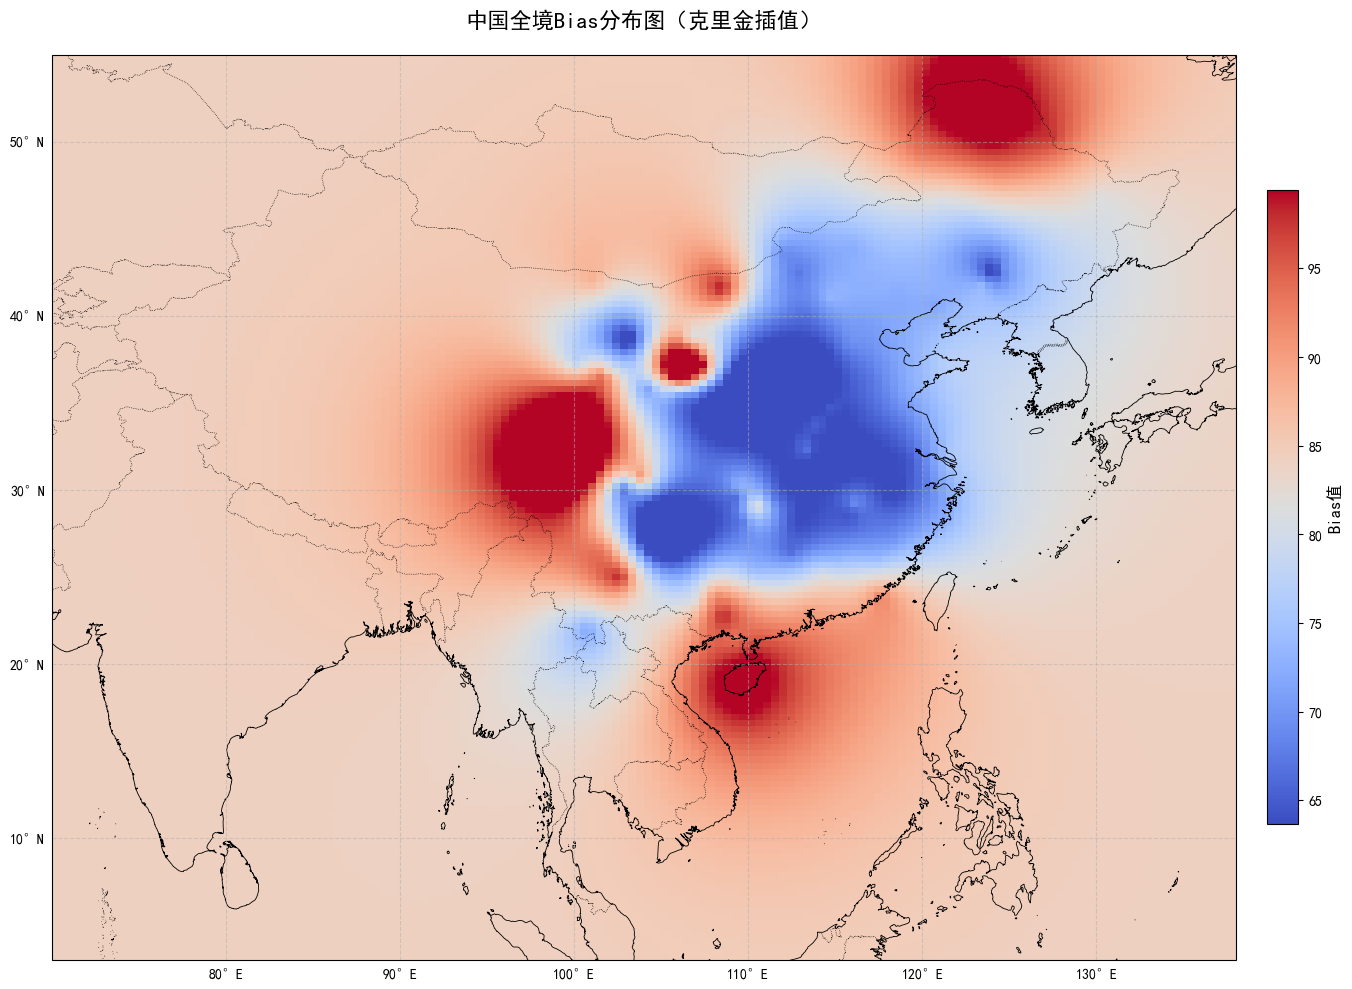

In [14]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging  # 引入克里金插值库

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，包含中国全境数据，并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 核心：将异常值替换为缺失值（NaN）
        # 包含9999、-999、999999，同时处理可能的字符串格式异常值
        异常值列表 = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(异常值列表, np.nan)
        
        # 过滤经纬度范围，并移除bias为缺失值的行
        valid_mask = (
            df['bias'].notna() &  # 仅保留非缺失的bias值
            df['Lon'].between(70, 138) &  # 东经70-138度
            df['Lat'].between(3, 55)      # 北纬3-55度
        )
        cleaned_df = df[valid_mask].copy()
        
        # 打印清洗信息（可选，用于调试）
        #print(f"文件 {os.path.basename(file)} 清洗后保留 {len(cleaned_df)} 条有效数据")
        return cleaned_df
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件并合并数据"""
    data_list = []
    for file in tqdm(file_list, desc="处理文件中"):
        try:
            filename = os.path.basename(file)
            date_str = filename.split('_')[-2][:8]
            date = datetime.strptime(date_str, "%Y%m%d").date()
            
            df = safe_read_csv(file)
            if df is not None and not df.empty:
                df['Date'] = date
                data_list.append(df[['Date', 'Lon', 'Lat', 'bias']])
        except Exception as e:
            print(f"处理文件 {filename} 时出错: {str(e)}")
    
    if not data_list:
        raise ValueError("未找到有效数据")
    all_data = pd.concat(data_list, ignore_index=True, copy=False)
    
    # 再次检查并清洗合并后的数据（双重保障）
    # all_data['bias'] = all_data['bias'].replace([9999, -999, 999999], np.nan).dropna() # 去除NaN
    # print(f"所有文件合并后共保留 {len(all_data)} 条有效数据")
    return all_data

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """使用普通克里金方法进行插值"""
    # 创建网格点
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    # 执行克里金插值（尝试更稳健的模型）
    OK = OrdinaryKriging(
        lon, lat, values, 
        variogram_model='exponential',  # 指数模型可能更适合部分数据
        verbose=False, 
        enable_plotting=False,
        nlags=8,  # 增加滞后距离数，提高稳定性
    )
    
    # 插值计算
    z, ss = OK.execute('grid', gridx, gridy)
    return z

def plot_china_bias(data):
    """绘制覆盖中国全境的Bias填色图（使用克里金插值）"""
    # 计算站点平均值（所有日期）
    station_avg = data.groupby(['Lon', 'Lat'], as_index=False)['bias'].mean()
    
    # 再次清洗平均值中的异常值（防止极端值影响）
    bias_mean = station_avg['bias'].mean()
    bias_std = station_avg['bias'].std()
    # 保留均值±3倍标准差范围内的数据（3σ准则）
    station_avg = station_avg[
        (station_avg['bias'] >= bias_mean - 3*bias_std) &
        (station_avg['bias'] <= bias_mean + 3*bias_std)
    ]
    print(f"站点平均值清洗后保留 {len(station_avg)} 个有效站点")
    
    # 创建覆盖中国全境的网格
    grid_lon = np.linspace(70, 138, 150, dtype='float32')
    grid_lat = np.linspace(3, 55, 150, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 准备克里金插值数据
    lon = station_avg['Lon'].values
    lat = station_avg['Lat'].values
    bias = station_avg['bias'].values
    
    # 执行克里金插值
    print("正在执行克里金插值...（可能需要几分钟）")
    grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
    
    # 创建图形
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
    # 添加高精度地图要素
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='#E6F7FF', alpha=0.2)
    
    # 设置中国全境范围
    ax.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    # 动态调整颜色映射范围（关键：基于实际数据分布）
    vmin = np.nanpercentile(grid_bias, 2)  # 排除2%的极端小值
    vmax = np.nanpercentile(grid_bias, 98)  # 排除2%的极端大值
    
    # 绘制填色图
    pcm = ax.pcolormesh(
        grid_lon, grid_lat, grid_bias,
        cmap='coolwarm',
        vmin=vmin, vmax=vmax,  # 自适应数据范围
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    # 添加颜色条
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Bias值', fontsize=12)
    
    # 添加网格和标题
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    plt.title('中国全境Bias分布图（克里金插值）', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()


def main():
    # 文件路径设置
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI-correct_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    all_data = process_files(file_list)
    
    # 绘制中国全境填色图
    print("生成中国全境Bias填色图...")
    plot_china_bias(all_data)

if __name__ == '__main__':
    main()